In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

In [2]:
# CSVファイルを読み込み
trajectory_file_path = "../practice/data/0527walking_trajectory.csv"
df = pd.read_csv(trajectory_file_path)

# 必要な列があるか確認
if not set(['time','x', 'y',]).issubset(df.columns):
    raise ValueError("CSVに 'time','x', 'y',列が必要です")


# X-tグラフの描画

## データ抽出

In [3]:
# xの移動距離 = 現在のX座標 - 初期x座標
x_distance = df['x'] - df['x'].iloc[0] # iloc[n]はデータにより可変
y_distance = df['y'] - df['y'].iloc[0]


total_distance  = np.sqrt(x_distance**2 + y_distance**2)
time = df['time']

# 結果をDataFrameにまとめる
total_distance_df= pd.DataFrame({
	'time':time,
	'total_distance':total_distance,
	})

print(total_distance_df)        


     time  total_distance
0    7.25        0.000000
1    7.50        0.188277
2    7.75        0.376553
3    8.00        0.550545
4    8.25        0.727005
5    8.50        0.906187
6    8.75        1.086233
7    9.00        1.261742
8    9.25        1.433917
9    9.50        1.608457
10   9.75        1.787485
11  10.00        1.961507
12  10.25        1.974202
13  10.50        1.986897
14  10.75        1.999593
15  11.00        2.012290
16  11.25        2.024987
17  11.50        2.037685
18  11.75        2.050383
19  12.00        2.063082
20  12.25        2.075781
21  12.50        2.088480
22  12.75        2.101180
23  13.00        2.113881
24  13.25        2.126582
25  13.50        2.139283
26  13.75        2.151985
27  14.00        2.164687
28  14.25        2.177389
29  14.50        2.190092
30  14.75        2.202796
31  15.00        2.215500
32  15.25        2.228204
33  15.50        2.240908
34  15.75        2.253613
35  16.00        2.266319
36  16.25        2.279024
37  16.50   

## グラフの描画

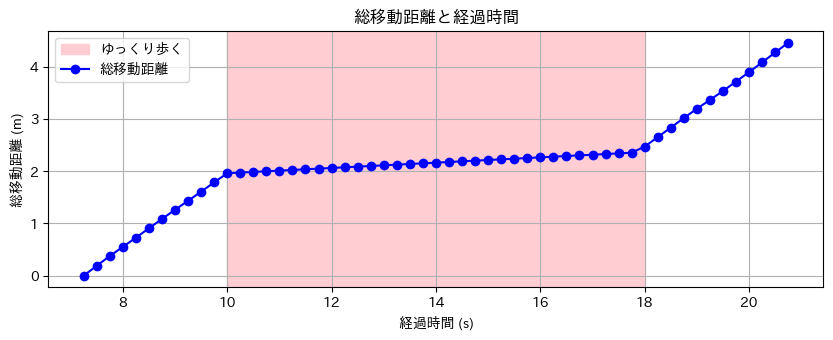

In [4]:

plt.figure(figsize=(10, 5))
plt.axvspan(10, 18,alpha=1.0,color="#ffcdd2",label='ゆっくり歩く')
plt.plot(total_distance_df['time'], total_distance_df['total_distance'], marker='o', linestyle='-', color='blue', label='総移動距離')
plt.xlabel('経過時間 (s)')
plt.ylabel('総移動距離 (m)')
plt.title('総移動距離と経過時間')
# 軸を揃える
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.legend()

In [5]:

# 座標差分と時間差分を計算
dt = df['time'].diff()
dx = df['x'].diff()
dy = df['y'].diff()

# 各点間の移動距離 (ds) = sqrt(dx^2 + dy^2)
ds = np.sqrt(dx**2 + dy**2)

speed = ds / dt

df_speed = pd.DataFrame({
    'time': df['time'].iloc[1:].reset_index(drop=True), 
    'speed': speed.iloc[1:].reset_index(drop=True)
})

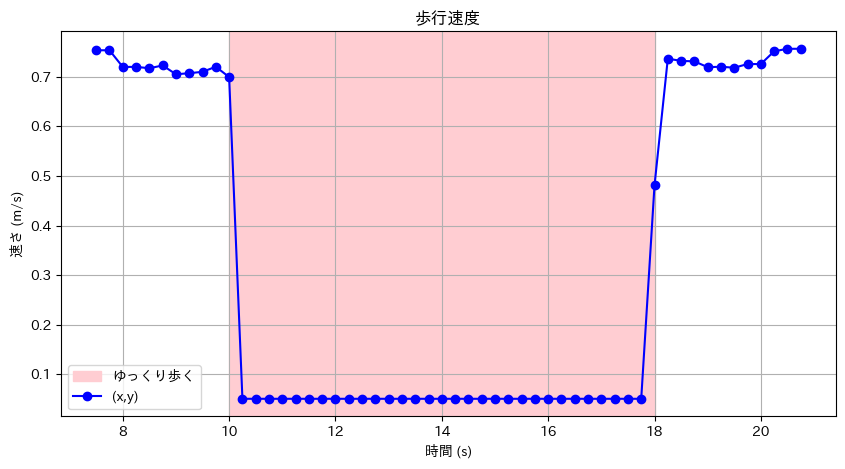

In [6]:
# 出力ファイル名
# output_csv = "speedSlowly.csv"

# CSV出力
# df_speed.to_csv(output_csv, index=False)

# 時間も1行目を除いて整形（速度と対応する時間）
speed = df_speed['speed'] 
time = df_speed['time'][1:].reset_index(drop=True)

# グラフ描画
plt.figure(figsize=(10, 5))
plt.axvspan(10, 18,alpha=1.0,color="#ffcdd2",label='ゆっくり歩く')
plt.plot(df_speed['time'], df_speed['speed'], marker='o', linestyle='-', color='blue', label='(x,y)')
plt.xlabel('時間 (s)')
plt.ylabel('速さ (m/s)')
plt.title('歩行速度')
plt.grid(True)
plt.legend()

### 赤い区間の（15.0秒から27.0秒）の平均速度の算出

In [7]:
start_time = 10.0
end_time = 18.0

# 範囲内のデータをフィルタリング
speed_filtered_range = df_speed[(df_speed['time'] >= start_time) & (df_speed['time'] <= end_time)]

# 平均速度を計算
if not speed_filtered_range.empty:
    average_speed_highlight = speed_filtered_range['speed'].mean()
    print(f"\n赤い区間 ({start_time}秒から{end_time}秒) の平均歩行速度: {average_speed_highlight:.4f} m/s")
else:
    print(f"\n赤い区間 ({start_time}秒から{end_time}秒) に対応する速度データがありません。")



赤い区間 (10.0秒から18.0秒) の平均歩行速度: 0.0836 m/s


##  平滑化フィルタをかける


## 移動平均フィルタ

     time     speed  low_speed
0    7.50  0.753107        NaN
1    7.75  0.753107   0.753107
2    8.00  0.719489   0.736298
3    8.25  0.719694   0.719592
4    8.50  0.716873   0.718283
5    8.75  0.722508   0.719690
6    9.00  0.704780   0.713644
7    9.25  0.706880   0.705830
8    9.50  0.709709   0.708294
9    9.75  0.719905   0.714807
10  10.00  0.699085   0.709495
11  10.25  0.050950   0.375017
12  10.50  0.050950   0.050950
13  10.75  0.050950   0.050950
14  11.00  0.050950   0.050950
15  11.25  0.050950   0.050950
16  11.50  0.050950   0.050950
17  11.75  0.050950   0.050950
18  12.00  0.050950   0.050950
19  12.25  0.050950   0.050950
20  12.50  0.050950   0.050950
21  12.75  0.050950   0.050950
22  13.00  0.050950   0.050950
23  13.25  0.050950   0.050950
24  13.50  0.050950   0.050950
25  13.75  0.050950   0.050950
26  14.00  0.050950   0.050950
27  14.25  0.050950   0.050950
28  14.50  0.050950   0.050950
29  14.75  0.050950   0.050950
30  15.00  0.050950   0.050950
31  15.2

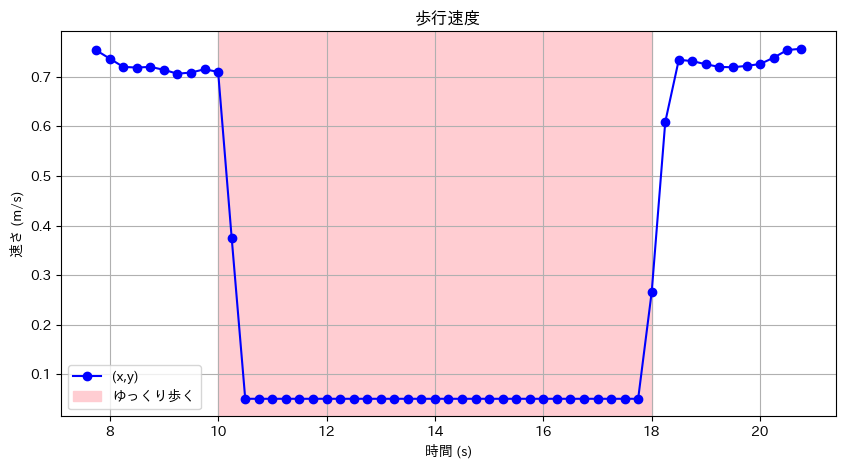

In [8]:
#　ウィンドウの宣言
window_speed=2

df_speed['low_speed']= df_speed['speed'].rolling(window=window_speed).mean()

print(df_speed)
output_csv = "data/speedStraight.csv"
# CSV出力
df_speed.to_csv(output_csv, index=False)


# グラフ描画
plt.figure(figsize=(10, 5))
plt.plot(df_speed['time'], df_speed['low_speed'], marker='o', linestyle='-', color='blue', label='(x,y)')
plt.axvspan(10.0, 18.0,alpha=1.0,color="#ffcdd2",label='ゆっくり歩く')
plt.xlabel('時間 (s)')
plt.ylabel('速さ (m/s)')
plt.title('歩行速度')
plt.grid(True)
plt.legend()